# [가설검증] 4억의 성장 준비금, 월 400만 원씩 뽑아 써도 세후에 10년 버틸까?

투자·인출 조건을 입력하고 아래 코드 셀을 실행하세요. 시작연도별 세후 잔액과 고갈 여부를 비교합니다.

분할매수 전 준비금은 원화 단기 금융상품에 보관하고, 매월 QQQ 매수에 필요한 금액만 달러로 환전합니다. 원화 대기자금에는 한국의 대표적인 단기 시장금리인 CD 91일물 금리를 적용합니다.

## 계좌 전략별 생존 시작연도 수

- **세전 기준**: 15/15
- **미국계좌**: 15/15
- **절세계좌**: 15/15

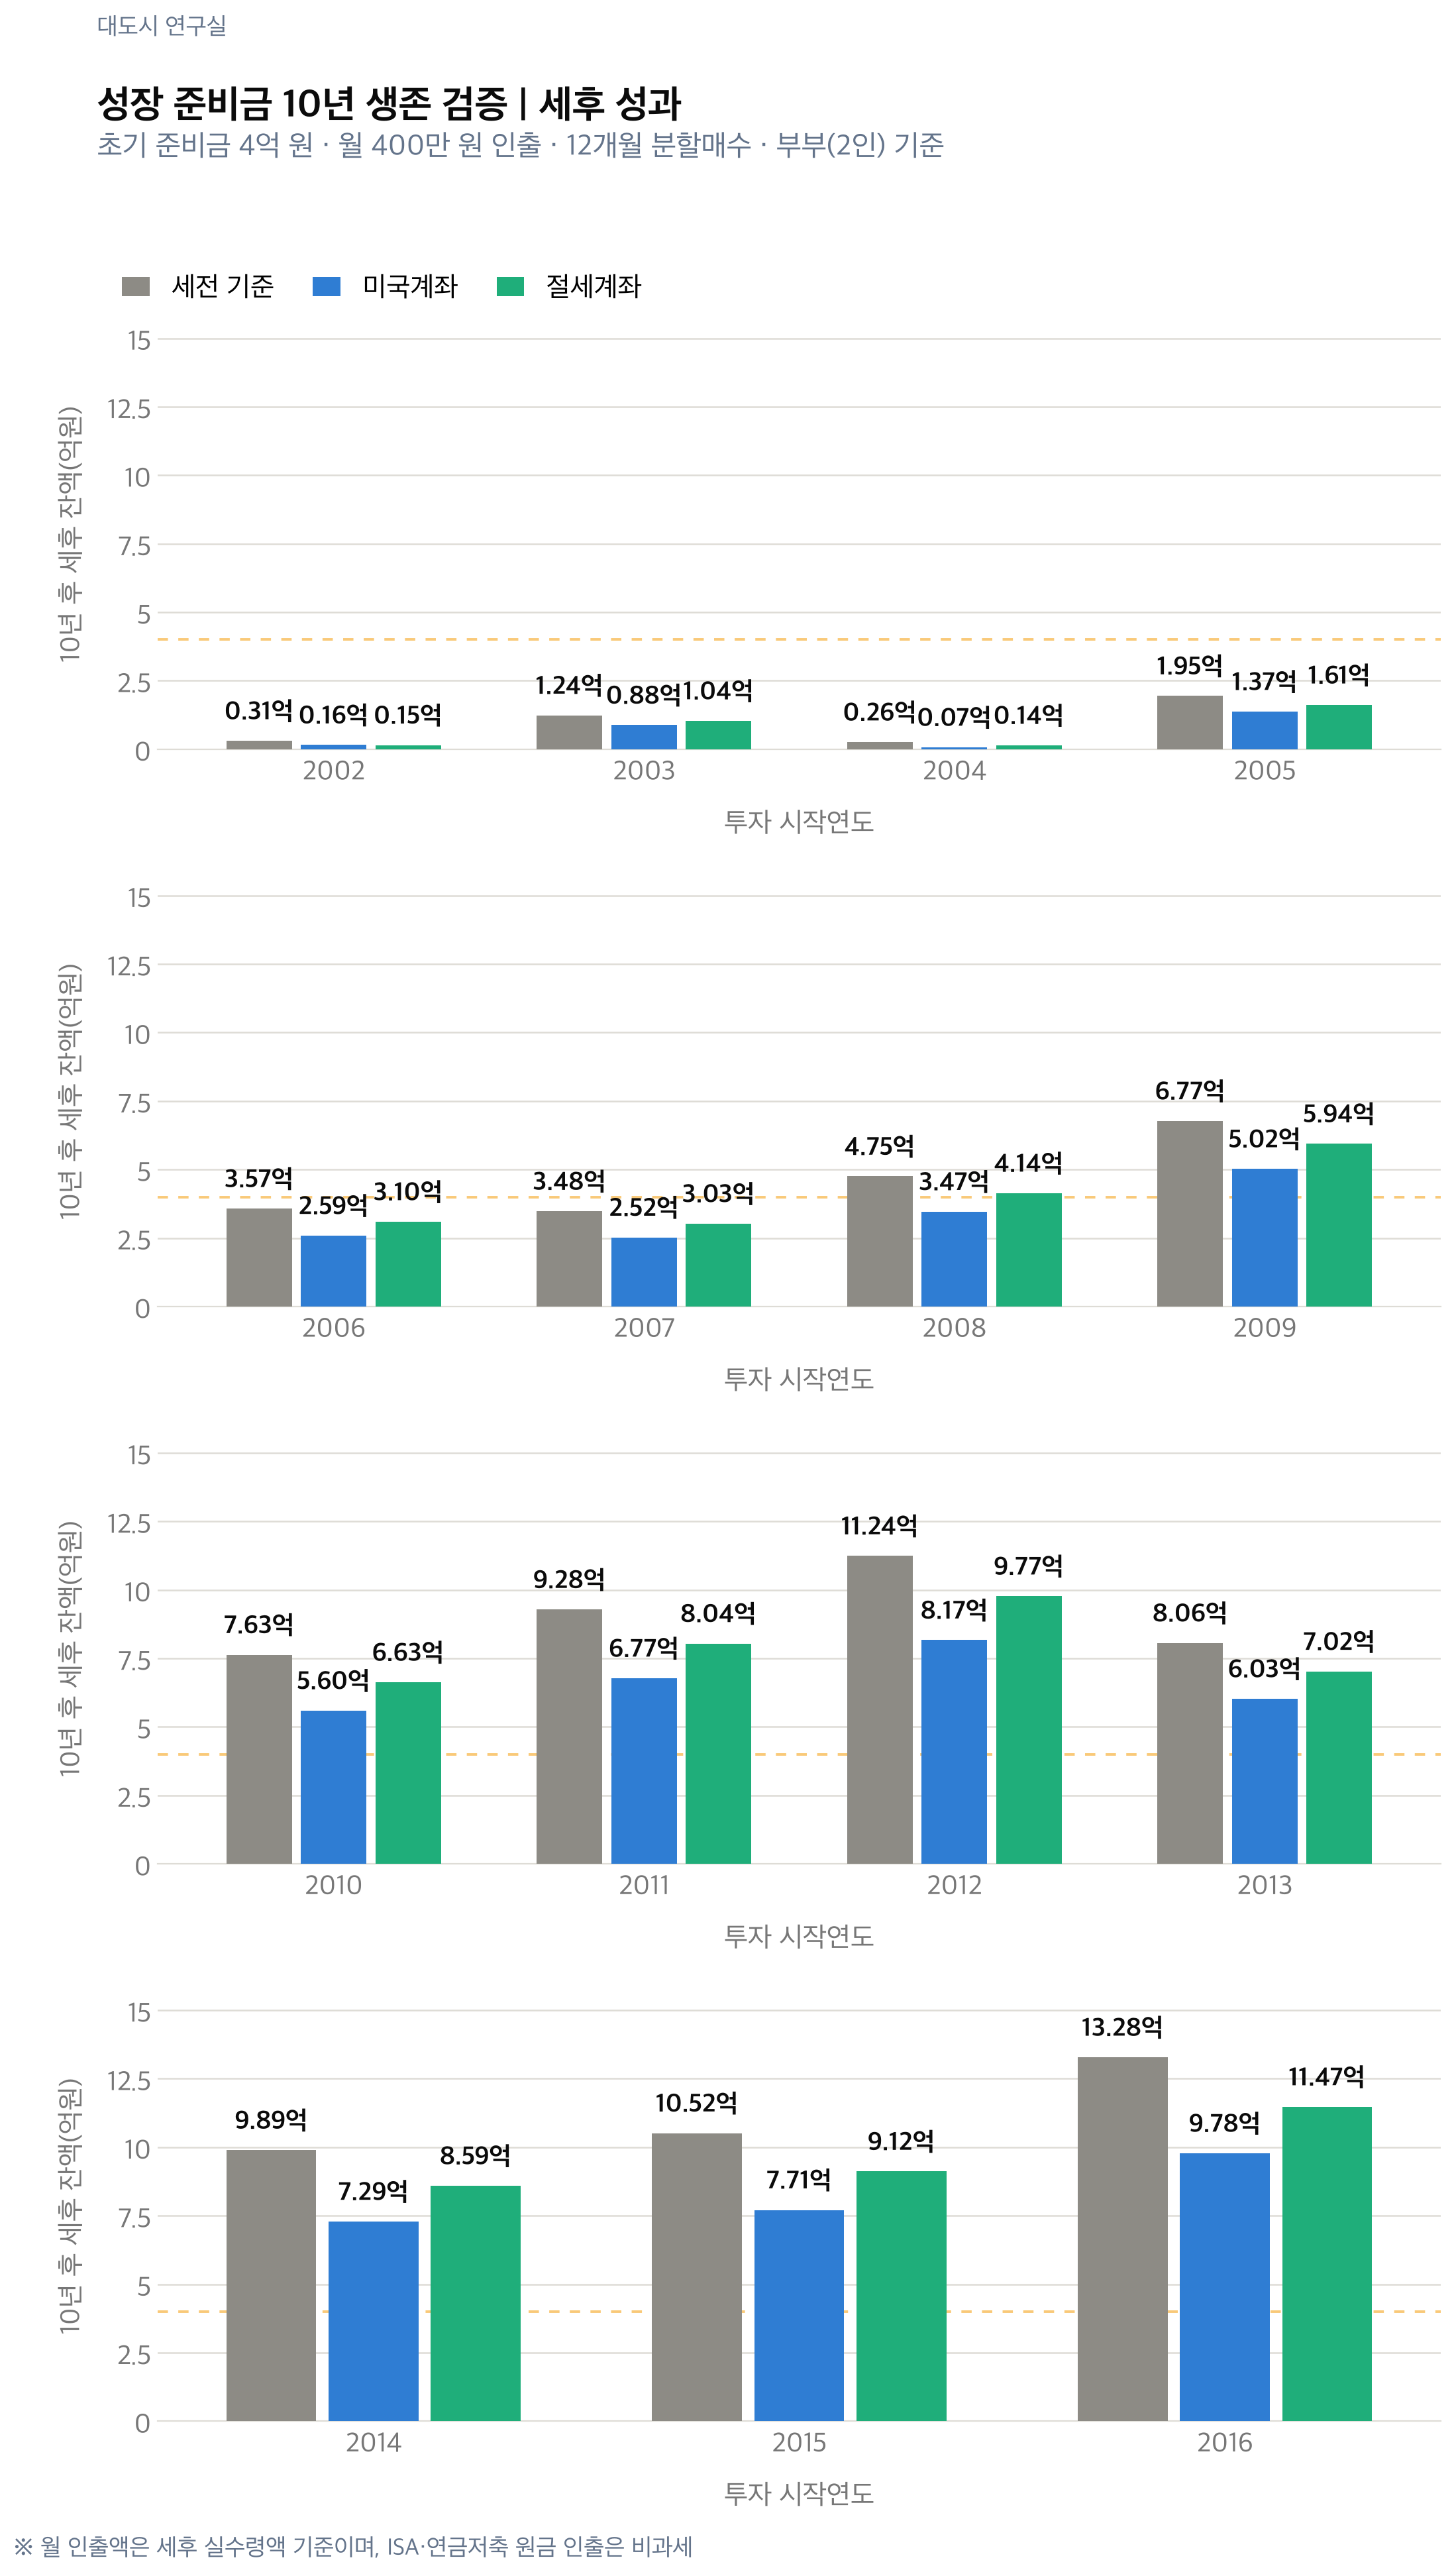

시작연도,세전 기준,미국계좌,절세계좌
2002,"3,088만원","1,553만원","1,497만원"
2003,"1억 2,373만원","8,793만원",1억 376만원
2004,"2,600만원",677만원,"1,413만원"
2005,"1억 9,474만원","1억 3,741만원","1억 6,124만원"
2006,"3억 5,734만원","2억 5,900만원",3억 965만원
2007,"3억 4,789만원","2억 5,239만원",3억 275만원
2008,"4억 7,521만원","3억 4,660만원","4억 1,373만원"
2009,"6억 7,742만원",5억 238만원,"5억 9,420만원"
2010,"7억 6,339만원","5억 5,968만원","6억 6,286만원"
2011,"9억 2,805만원","6억 7,747만원",8억 447만원


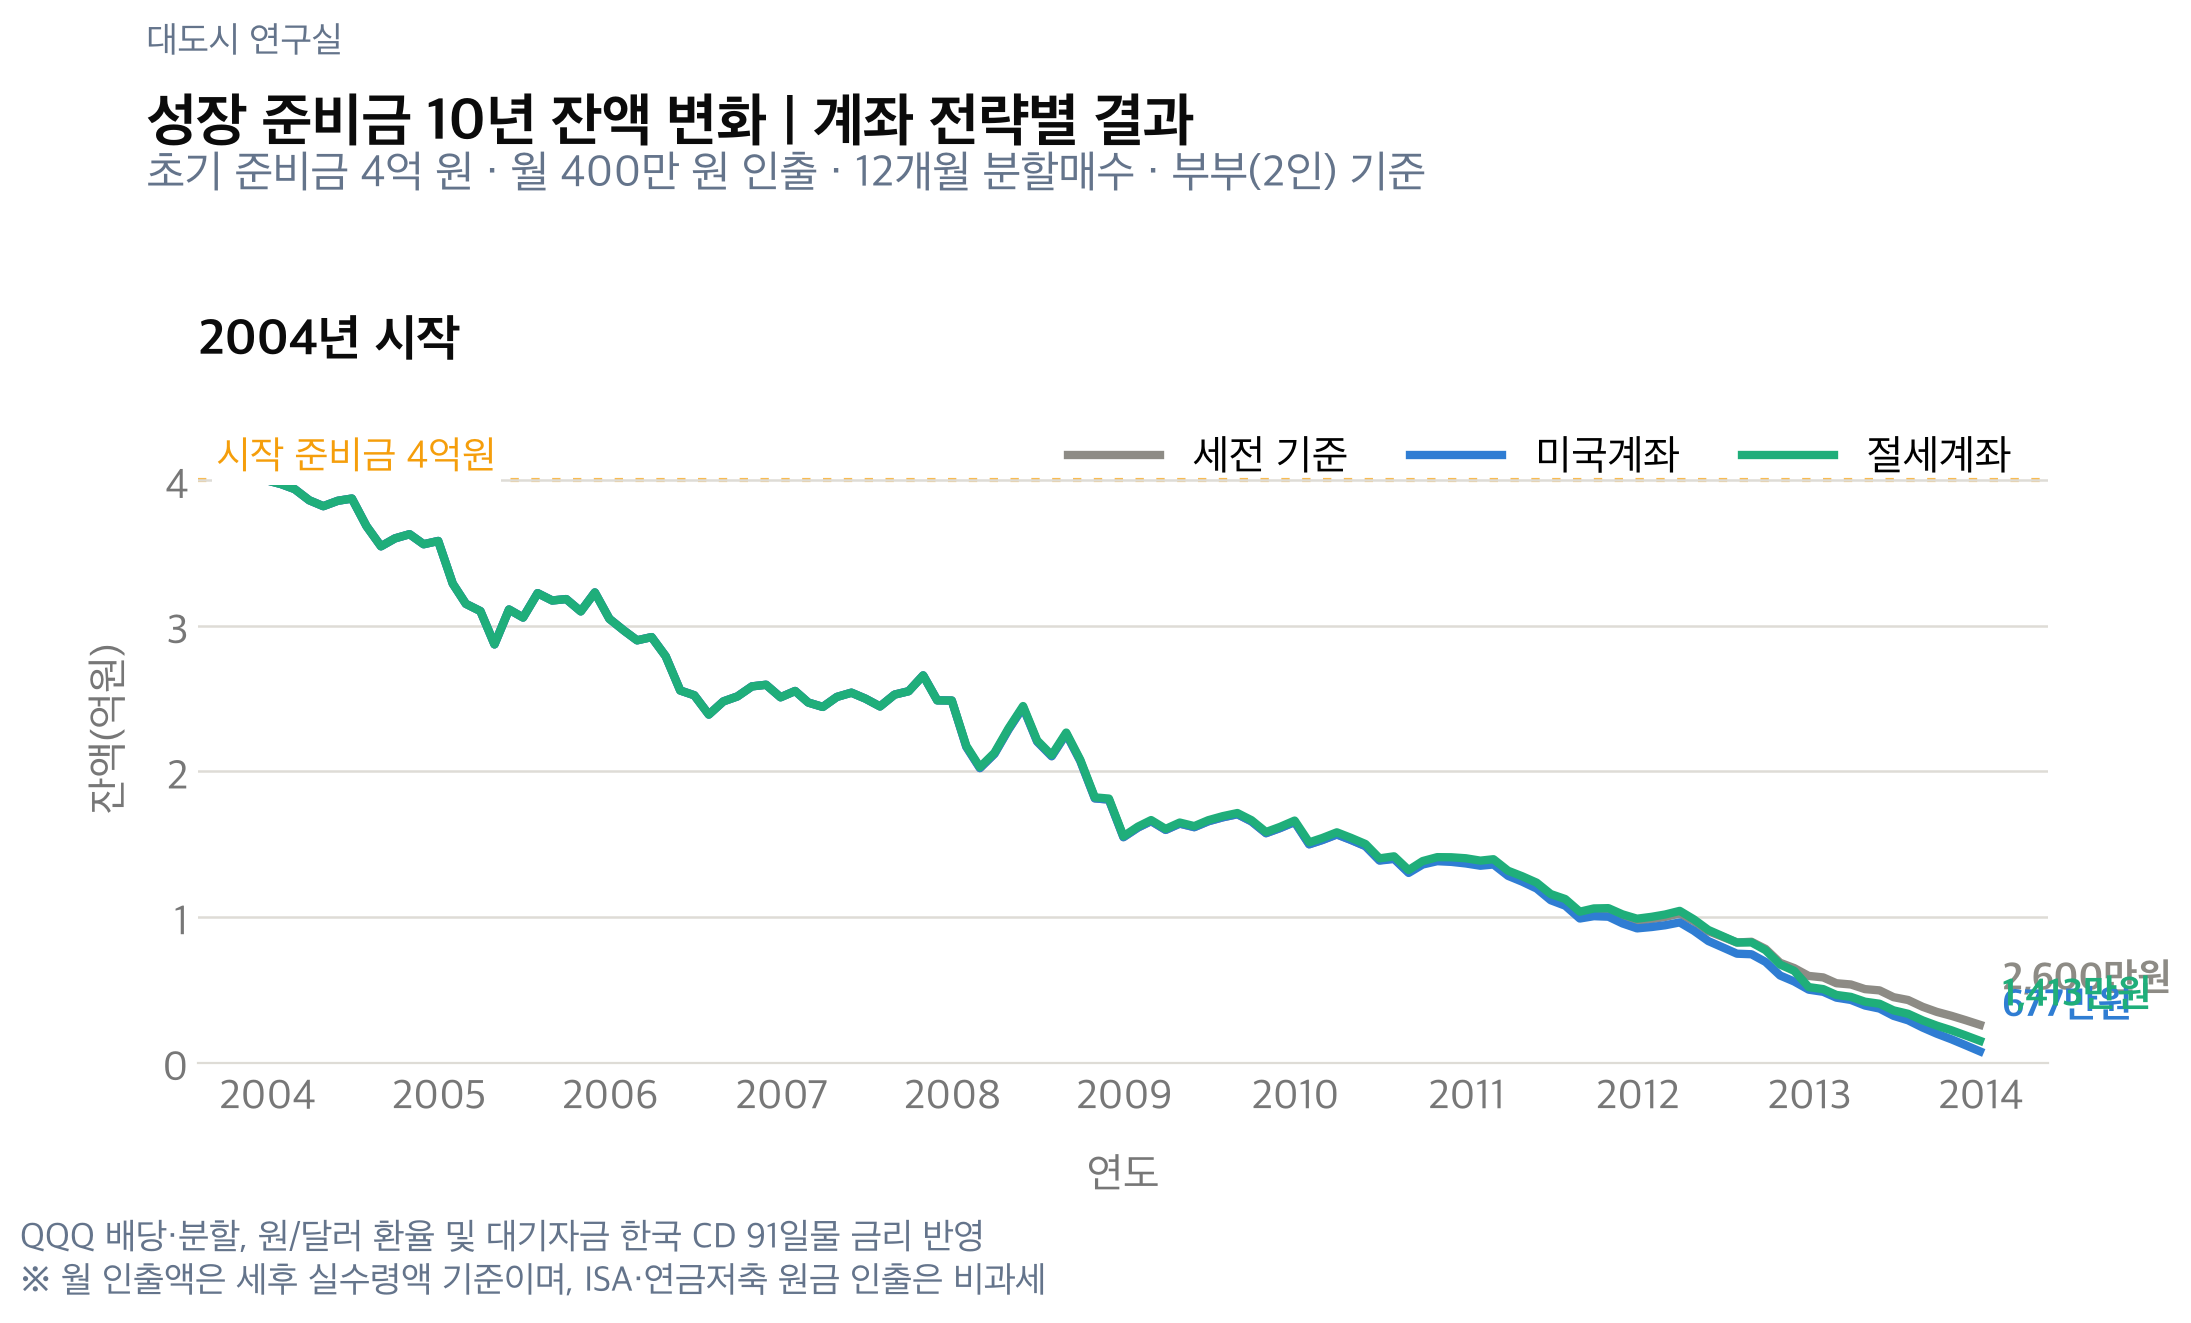

저장 완료:
output/qqq_account_strategy_summary.csv
output/qqq_account_strategy_monthly_detail.csv
output/qqq_account_strategy_monthly_balance_2004.csv
output/qqq_account_strategy_ending_balance.png
output/qqq_account_strategy_balance_flow_2004.png


In [3]:
# @title 계좌 전략별 성장 준비금 조건을 입력하세요
최초_시작연도 = 2002  # @param {type:"integer", min:2000, step:1}
마지막_시작연도 = 2016  # @param {type:"integer", min:2000, step:1}
월별잔액_표시연도 = 2004  # @param {type:"integer", min:2000, step:1}
초기준비금_억원 = 4.0  # @param {type:"number", min:0.01, step:0.1}
월실수령액_만원 = 400  # @param {type:"number", min:0, step:10}
투자기간_년 = 10  # @param {type:"integer", min:1, step:1}
분할매수기간_개월 = 12  # @param {type:"integer", min:1, max:24, step:1}

"""QQQ 투자 시 계좌 전략별 세후 정기 인출 결과를 비교한다.

QQQ 수정주가는 Yahoo Finance, 원/달러 환율은 미국 연준 FRED의
DEXKOUS, 대기자금 수익률은 한국은행 ECOS CD 91일물 월별 금리를
사용한다. 분할매수 전 준비금은 원화 단기 금융상품으로 운용하고, 매월 말
세후 실수령액을 먼저 인출한 뒤 필요한 QQQ 매수액만 달러로 환전한다.

절세계좌는 부부 두 사람의 ISA 누적 납입한도와 연금계좌 연간 한도를
활용한다. ISA와 연금계좌에서는 국내 상장 나스닥100 ETF가 QQQ와 같은
수익률을 낸다고 가정한다. ISA는 납입원금 범위에서 세금 없이 중도인출하고,
원금 소진 후 해지할 때 전체 순이익을 정산한다. 3년 전 중도해지는 15.4%,
3년 이후 정상해지는 비과세 한도 공제 후 9.9%를 적용한다. 해지 잔액은
새 ISA에 즉시 재투자한다. 연금저축 납입금은 세액공제를 받지 않으며,
원금은 비과세로 먼저 인출하고 이후 연금 외 수령액에 16.5%를 적용한다.
상품 보수와 추적오차는
반영하지 않는다.
"""

from dataclasses import dataclass
import json
import math
import os
from pathlib import Path
import subprocess
import sys
from typing import Any, cast
from urllib.request import urlopen, urlretrieve

import matplotlib
matplotlib.use("Agg")
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager
from matplotlib.axes import Axes
from matplotlib.patches import Patch
import pandas as pd
from IPython.display import HTML, Image, Markdown, display


def is_colab_runtime() -> bool:
    """현재 코드가 Google Colab에서 실행 중인지 확인한다."""
    return bool(os.environ.get("COLAB_RELEASE_TAG")) or Path("/content").exists()


IS_COLAB = is_colab_runtime()
OUTPUT_DIR = Path("/content/output") if IS_COLAB else Path("output")
WON_PER_EOK = 100_000_000
WON_PER_MANWON = 10_000
MONTHS_PER_YEAR = 12
TICKER = "QQQ"
FIRST_START_YEAR = int(최초_시작연도)
LAST_START_YEAR = int(마지막_시작연도)
BALANCE_DISPLAY_YEAR = int(월별잔액_표시연도)
INITIAL_RESERVE_KRW = float(초기준비금_억원) * WON_PER_EOK
MONTHLY_NET_WITHDRAWAL_KRW = float(월실수령액_만원) * WON_PER_MANWON
INVESTMENT_YEARS = int(투자기간_년)
DCA_MONTHS = int(분할매수기간_개월)
TOTAL_MONTHS = INVESTMENT_YEARS * MONTHS_PER_YEAR
INVESTOR_COUNT = 2
US_DEDUCTION_KRW = 2_500_000 * INVESTOR_COUNT
US_TAX_RATE = 0.22
GENERAL_TAX_RATE = 0.154
ISA_EXEMPTION_KRW = 2_000_000 * INVESTOR_COUNT
ISA_TAX_RATE = 0.099
PENSION_TAX_RATE = 0.165
ISA_ANNUAL_LIMIT_KRW = 20_000_000 * INVESTOR_COUNT
ISA_MAX_KRW = 100_000_000 * INVESTOR_COUNT
ISA_TERM_MONTHS = 36
PENSION_ANNUAL_LIMIT_KRW = 18_000_000 * INVESTOR_COUNT
US_CORE_KRW = 25_000_000 * INVESTOR_COUNT
GENERAL_MAX_KRW = 200_000_000 * INVESTOR_COUNT
WITHDRAWAL_ORDER = (
    "us_excess",
    "general",
    "pension_principal",
    "isa_principal",
    "us_core",
    "pension_taxable",
    "isa_close",
)
STRATEGIES = ("세전 기준", "미국계좌", "절세계좌")
STRATEGY_COLORS = {
    "세전 기준": "#8D8B85",
    "미국계좌": "#2F7DD3",
    "절세계좌": "#1FAE7A",
}
BACKGROUND_COLOR = "#FFFFFF"
TEXT_COLOR = "#0B0B0B"
SECONDARY_TEXT_COLOR = "#64748B"
TICK_COLOR = "#777777"
GRID_COLOR = "#DEDCD6"
DEPLETION_COLOR = "#F06432"
REFERENCE_COLOR = "#F59E0B"
BRAND_SIZE = 13
TITLE_SIZE = 21
SUBTITLE_SIZE = 16
PANEL_TITLE_SIZE = 18
AXIS_TITLE_SIZE = 15
TICK_SIZE = 15
LEGEND_SIZE = 15
DATA_LABEL_SIZE = 14
REFERENCE_LABEL_SIZE = 14
FOOTNOTE_SIZE = 13

try:
    import yfinance as yf
except ImportError:
    if not IS_COLAB:
        raise
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])
    import yfinance as yf


@dataclass
class Account:
    """계좌의 현금, QQQ 수량과 세금 계산용 원금을 보관한다."""
    cash_krw: float = 0.0
    shares: float = 0.0
    basis_krw: float = 0.0


@dataclass
class Portfolio:
    """절세계좌 전략의 계좌와 남은 공제액을 보관한다."""
    us: Account
    general: Account
    pension: Account
    isa: Account
    us_excess_cash_krw: float = 0.0
    us_deduction_remaining_krw: float = US_DEDUCTION_KRW
    isa_exemption_remaining_krw: float = ISA_EXEMPTION_KRW
    isa_principal_remaining_krw: float = 0.0
    isa_lifetime_contributed_krw: float = 0.0
    isa_age_months: int = ISA_TERM_MONTHS
    isa_closed: bool = False
    pension_principal_remaining_krw: float = 0.0
    taxes_paid_krw: float = 0.0


def validate_parameters() -> None:
    """입력값과 인출 순서를 검증한다."""
    if FIRST_START_YEAR < 2000 or FIRST_START_YEAR > LAST_START_YEAR:
        raise ValueError("시작연도 범위를 2000년 이후로 올바르게 입력하세요.")
    if not FIRST_START_YEAR <= BALANCE_DISPLAY_YEAR <= LAST_START_YEAR:
        raise ValueError("월별잔액_표시연도는 시작연도~마지막_시작연도 범위여야 합니다.")
    if INITIAL_RESERVE_KRW <= 0 or INVESTMENT_YEARS <= 0:
        raise ValueError("초기 준비금과 투자기간은 0보다 커야 합니다.")
    if MONTHLY_NET_WITHDRAWAL_KRW < 0:
        raise ValueError("월 실수령액은 0원 이상이어야 합니다.")
    if not 1 <= DCA_MONTHS <= 24:
        raise ValueError("분할매수기간은 1~24개월이어야 합니다.")


def download_monthly_prices() -> pd.Series:
    """Yahoo Finance에서 QQQ 월말 수정주가를 내려받는다."""
    raw = yf.download(
        TICKER, start=f"{FIRST_START_YEAR - 1}-12-01",
        end=f"{LAST_START_YEAR + INVESTMENT_YEARS + 1}-01-10",
        auto_adjust=False, progress=False, actions=False,
    )
    if raw is None or raw.empty:
        raise RuntimeError("QQQ 가격 데이터를 내려받지 못했습니다.")
    prices = raw["Adj Close"]
    if isinstance(prices, pd.DataFrame):
        frame = cast(pd.DataFrame, prices)
        prices = frame[TICKER] if TICKER in frame.columns else frame.iloc[:, 0]
    prices = prices.dropna().astype(float)
    prices.index = pd.to_datetime(prices.index).tz_localize(None)
    return prices.resample("ME").last().rename(TICKER)


def download_monthly_usdkrw() -> pd.Series:
    """FRED에서 월말 원/달러 환율을 내려받는다."""
    start = f"{FIRST_START_YEAR - 1}-12-01"
    end = f"{LAST_START_YEAR + INVESTMENT_YEARS}-12-31"
    url = (
        "https://fred.stlouisfed.org/graph/fredgraph.csv"
        f"?id=DEXKOUS&cosd={start}&coed={end}"
    )
    raw = pd.read_csv(url)
    date_column = "observation_date" if "observation_date" in raw.columns else "DATE"
    dates = pd.to_datetime(raw[date_column])
    values = pd.to_numeric(raw["DEXKOUS"], errors="coerce")
    daily = pd.Series(values.to_numpy(), index=dates, name="usdkrw").dropna()
    return daily.resample("ME").last()


def download_monthly_cd91_rates() -> pd.Series:
    """월별 CD 91일물 금리를 한국은행 ECOS에서 내려받는다."""
    start = f"{FIRST_START_YEAR - 1}12"
    end = f"{LAST_START_YEAR + INVESTMENT_YEARS}12"
    base_url = "https://ecos.bok.or.kr/api/StatisticSearch/sample/json/kr"

    def request_rows(start_row: int, end_row: int) -> dict[str, Any]:
        url = (
            f"{base_url}/{start_row}/{end_row}/721Y001/M/"
            f"{start}/{end}/2010000"
        )
        with urlopen(url, timeout=30) as response:
            payload = json.load(response)
        if "StatisticSearch" not in payload:
            message = payload.get("RESULT", {}).get(
                "MESSAGE", "알 수 없는 ECOS 오류"
            )
            raise RuntimeError(f"CD 91일물 금리를 받지 못했습니다: {message}")
        return payload["StatisticSearch"]

    first_page = request_rows(1, 10)
    total_count = int(first_page["list_total_count"])
    rows = list(first_page["row"])
    for start_row in range(11, total_count + 1, 10):
        end_row = min(start_row + 9, total_count)
        rows.extend(request_rows(start_row, end_row)["row"])

    dates = pd.to_datetime(
        [row["TIME"] for row in rows], format="%Y%m"
    ) + pd.offsets.MonthEnd(0)
    values = pd.to_numeric(
        [row["DATA_VALUE"] for row in rows], errors="coerce"
    )
    return pd.Series(
        values, index=dates, name="cd91_rate_percent"
    ).dropna()


def load_market_data() -> pd.DataFrame:
    """QQQ 수정주가, 환율과 한국 CD 91일물 금리를 결합한다."""
    return pd.concat(
        [
            download_monthly_prices(),
            download_monthly_usdkrw(),
            download_monthly_cd91_rates(),
        ],
        axis=1,
    )


def market_for_start(market: pd.DataFrame, start_year: int) -> pd.DataFrame:
    """한 시작연도의 10년 월말 데이터를 검증해 반환한다."""
    first_month = pd.Timestamp(start_year, 1, 31)
    trade_month = first_month - pd.offsets.MonthEnd(1)
    final_month = first_month + pd.offsets.MonthEnd(TOTAL_MONTHS - 1)
    required = market.loc[trade_month:final_month].copy()
    expected_count = TOTAL_MONTHS + 1
    if len(required) != expected_count or required.isna().any().any():
        raise RuntimeError(f"{start_year}년 시장 데이터 {expected_count}개월이 필요합니다.")
    return required


def account_value(account: Account, price_usd: float, fx_rate: float) -> float:
    """계좌의 원화 평가액을 계산한다."""
    return account.cash_krw + account.shares * price_usd * fx_rate


def buy_from_cash(account: Account, requested_krw: float, price_usd: float, fx_rate: float) -> float:
    """계좌 현금으로 QQQ를 매수하고 실제 매수액을 반환한다."""
    purchase_krw = min(max(requested_krw, 0.0), account.cash_krw)
    account.cash_krw -= purchase_krw
    account.shares += purchase_krw / (price_usd * fx_rate)
    account.basis_krw += purchase_krw
    return purchase_krw


def buy_sequentially_from_accounts(
    portfolio: Portfolio, requested_krw: float, price_usd: float, fx_rate: float
) -> float:
    """미국계좌 공제분부터 절세계좌·일반계좌·미국계좌 과세분 순으로 매수한다."""
    remaining_krw = max(requested_krw, 0.0)
    purchased_krw = 0.0
    for name in ("us", "isa", "pension", "general"):
        if remaining_krw <= 0.5:
            break
        account = getattr(portfolio, name)
        amount_krw = buy_from_cash(
            account, remaining_krw, price_usd, fx_rate
        )
        purchased_krw += amount_krw
        remaining_krw -= amount_krw
    if remaining_krw > 0.5 and portfolio.us_excess_cash_krw > 0.0:
        amount_krw = min(remaining_krw, portfolio.us_excess_cash_krw)
        portfolio.us_excess_cash_krw -= amount_krw
        portfolio.us.shares += amount_krw / (price_usd * fx_rate)
        portfolio.us.basis_krw += amount_krw
        purchased_krw += amount_krw
    return purchased_krw


def sell_shares_for_net(
    account: Account, requested_net_krw: float, max_gross_krw: float,
    price_usd: float, fx_rate: float, tax_rate: float, exemption_krw: float,
) -> tuple[float, float, float]:
    """세금을 낸 뒤 목표 실수령액이 되도록 보유 수량을 매도한다."""
    share_value_krw = account.shares * price_usd * fx_rate
    gross_limit_krw = min(max(max_gross_krw, 0.0), share_value_krw)
    if requested_net_krw <= 0 or gross_limit_krw <= 0:
        return 0.0, 0.0, exemption_krw
    gain_ratio = (
        max(share_value_krw - account.basis_krw, 0.0) / share_value_krw
        if share_value_krw > 0 else 0.0
    )

    def net_from_gross(gross_krw: float) -> float:
        gain_krw = gross_krw * gain_ratio
        tax_krw = max(gain_krw - exemption_krw, 0.0) * tax_rate
        return gross_krw - tax_krw

    if gain_ratio <= 0 or requested_net_krw * gain_ratio <= exemption_krw:
        gross_needed_krw = requested_net_krw
    else:
        gross_needed_krw = (
            requested_net_krw - tax_rate * exemption_krw
        ) / (1 - tax_rate * gain_ratio)
    gross_sale_krw = min(max(gross_needed_krw, 0.0), gross_limit_krw)
    realized_gain_krw = gross_sale_krw * gain_ratio
    tax_krw = max(realized_gain_krw - exemption_krw, 0.0) * tax_rate
    net_krw = gross_sale_krw - tax_krw
    sold_fraction = gross_sale_krw / share_value_krw
    account.shares *= max(1 - sold_fraction, 0.0)
    account.basis_krw *= max(1 - sold_fraction, 0.0)
    exemption_krw = max(exemption_krw - realized_gain_krw, 0.0)
    return min(net_krw, net_from_gross(gross_limit_krw)), tax_krw, exemption_krw


def withdraw_net_from_account(
    account: Account, requested_net_krw: float, price_usd: float, fx_rate: float,
    tax_rate: float, exemption_krw: float = 0.0, floor_krw: float = 0.0,
) -> tuple[float, float, float]:
    """계좌 평가액 하한을 지키며 세후 실수령액을 인출한다."""
    available_gross_krw = max(account_value(account, price_usd, fx_rate) - floor_krw, 0.0)
    cash_withdrawal_krw = min(account.cash_krw, requested_net_krw, available_gross_krw)
    account.cash_krw -= cash_withdrawal_krw
    remaining_net_krw = requested_net_krw - cash_withdrawal_krw
    remaining_gross_krw = available_gross_krw - cash_withdrawal_krw
    sale_net_krw, tax_krw, exemption_krw = sell_shares_for_net(
        account, remaining_net_krw, remaining_gross_krw,
        price_usd, fx_rate, tax_rate, exemption_krw,
    )
    return cash_withdrawal_krw + sale_net_krw, tax_krw, exemption_krw


def withdraw_from_us_excess(
    portfolio: Portfolio, requested_net_krw: float, price_usd: float, fx_rate: float
) -> tuple[float, float]:
    """미국계좌 과세분 예수금에서 인출한다. 공제분 계좌는 별개 계좌로 취급해 건드리지 않는다."""
    cash_krw = min(portfolio.us_excess_cash_krw, max(requested_net_krw, 0.0))
    portfolio.us_excess_cash_krw -= cash_krw
    return cash_krw, 0.0


def withdraw_principal_tax_free(
    account: Account, principal_remaining_krw: float, requested_krw: float,
    price_usd: float, fx_rate: float,
) -> tuple[float, float]:
    """계좌 납입원금 범위에서 세금 없이 중도인출하고, (인출액, 남은 원금)을 반환한다."""
    available_krw = account_value(account, price_usd, fx_rate)
    withdrawal_krw = min(max(requested_krw, 0.0), principal_remaining_krw, available_krw)
    cash_krw = min(account.cash_krw, withdrawal_krw)
    account.cash_krw -= cash_krw
    sale_krw = withdrawal_krw - cash_krw
    if sale_krw > 0.0:
        share_value_krw = account.shares * price_usd * fx_rate
        sold_fraction = min(sale_krw / share_value_krw, 1.0)
        account.shares *= max(1 - sold_fraction, 0.0)
        account.basis_krw *= max(1 - sold_fraction, 0.0)
    return withdrawal_krw, principal_remaining_krw - withdrawal_krw


def withdraw_isa_principal(
    portfolio: Portfolio, requested_krw: float, price_usd: float, fx_rate: float
) -> float:
    """ISA 납입원금 범위에서 세금 없이 중도인출한다."""
    if portfolio.isa_closed:
        return 0.0
    withdrawal_krw, portfolio.isa_principal_remaining_krw = withdraw_principal_tax_free(
        portfolio.isa, portfolio.isa_principal_remaining_krw, requested_krw, price_usd, fx_rate,
    )
    if account_value(portfolio.isa, price_usd, fx_rate) <= 0.5:
        portfolio.isa = Account()
        portfolio.isa_principal_remaining_krw = 0.0
        portfolio.isa_closed = True
    return withdrawal_krw


def withdraw_pension_principal(
    portfolio: Portfolio, requested_krw: float, price_usd: float, fx_rate: float
) -> float:
    """세액공제받지 않은 연금저축 원금을 세금 없이 인출한다."""
    withdrawal_krw, portfolio.pension_principal_remaining_krw = withdraw_principal_tax_free(
        portfolio.pension, portfolio.pension_principal_remaining_krw, requested_krw, price_usd, fx_rate,
    )
    return withdrawal_krw


def withdraw_taxable_pension(
    portfolio: Portfolio, requested_net_krw: float, price_usd: float, fx_rate: float
) -> tuple[float, float]:
    """연금저축 과세분을 연금 외 수령하고 16.5%를 원천징수한다."""
    available_gross_krw = account_value(
        portfolio.pension, price_usd, fx_rate
    )
    gross_needed_krw = max(requested_net_krw, 0.0) / (1 - PENSION_TAX_RATE)
    gross_withdrawal_krw = min(gross_needed_krw, available_gross_krw)
    cash_krw = min(portfolio.pension.cash_krw, gross_withdrawal_krw)
    portfolio.pension.cash_krw -= cash_krw
    sale_krw = gross_withdrawal_krw - cash_krw
    if sale_krw > 0.0:
        share_value_krw = portfolio.pension.shares * price_usd * fx_rate
        sold_fraction = min(sale_krw / share_value_krw, 1.0)
        portfolio.pension.shares *= max(1 - sold_fraction, 0.0)
        portfolio.pension.basis_krw *= max(1 - sold_fraction, 0.0)
    tax_krw = gross_withdrawal_krw * PENSION_TAX_RATE
    return gross_withdrawal_krw - tax_krw, tax_krw


def close_isa(
    portfolio: Portfolio, requested_net_krw: float, price_usd: float, fx_rate: float
) -> tuple[float, float]:
    """ISA를 해지하고 생활비 차감 후 남은 재원을 미국계좌공제분→ISA→연금저축→일반계좌→미국계좌과세분 순으로 배분한다."""
    if portfolio.isa_closed:
        return 0.0, 0.0
    value_krw = account_value(portfolio.isa, price_usd, fx_rate)
    gain_krw = max(value_krw - portfolio.isa_principal_remaining_krw, 0.0)
    is_mature = portfolio.isa_age_months >= ISA_TERM_MONTHS
    tax_krw = (
        max(gain_krw - portfolio.isa_exemption_remaining_krw, 0.0)
        * ISA_TAX_RATE
        if is_mature
        else gain_krw * GENERAL_TAX_RATE
    )
    proceeds_krw = max(value_krw - tax_krw, 0.0)
    withdrawal_krw = min(max(requested_net_krw, 0.0), proceeds_krw)
    remaining_krw = proceeds_krw - withdrawal_krw

    us_core_value_krw = account_value(portfolio.us, price_usd, fx_rate)
    us_core_room_krw = max(US_CORE_KRW - us_core_value_krw, 0.0)
    us_core_krw = min(remaining_krw, us_core_room_krw)
    remaining_krw -= us_core_krw

    new_isa_krw = min(remaining_krw, ISA_ANNUAL_LIMIT_KRW)
    remaining_krw -= new_isa_krw

    pension_value_krw = account_value(portfolio.pension, price_usd, fx_rate)
    pension_room_krw = max(
        PENSION_ANNUAL_LIMIT_KRW - min(portfolio.pension_principal_remaining_krw, pension_value_krw), 0.0
    )
    pension_contribution_krw = min(remaining_krw, pension_room_krw)
    remaining_krw -= pension_contribution_krw

    general_room_krw = max(GENERAL_MAX_KRW - account_value(portfolio.general, price_usd, fx_rate), 0.0)
    general_cash_krw = min(remaining_krw, general_room_krw)
    remaining_krw -= general_cash_krw

    us_excess_krw = remaining_krw

    if us_core_krw > 0.0:
        portfolio.us.cash_krw += us_core_krw
        buy_from_cash(portfolio.us, us_core_krw, price_usd, fx_rate)
    if new_isa_krw > 0.0:
        portfolio.isa = Account(
            shares=new_isa_krw / (price_usd * fx_rate),
            basis_krw=new_isa_krw,
        )
        portfolio.isa_principal_remaining_krw = new_isa_krw
        portfolio.isa_lifetime_contributed_krw += new_isa_krw
        portfolio.isa_exemption_remaining_krw = ISA_EXEMPTION_KRW
        portfolio.isa_age_months = 0
        portfolio.isa_closed = False
    else:
        portfolio.isa = Account()
        portfolio.isa_principal_remaining_krw = 0.0
        portfolio.isa_exemption_remaining_krw = 0.0
        portfolio.isa_closed = True
    if pension_contribution_krw > 0.0:
        portfolio.pension.cash_krw += pension_contribution_krw
        buy_from_cash(portfolio.pension, pension_contribution_krw, price_usd, fx_rate)
        portfolio.pension_principal_remaining_krw += pension_contribution_krw
    if general_cash_krw > 0.0:
        portfolio.general.cash_krw += general_cash_krw
        buy_from_cash(portfolio.general, general_cash_krw, price_usd, fx_rate)
    if us_excess_krw > 0.0:
        portfolio.us_excess_cash_krw += us_excess_krw
    return withdrawal_krw, tax_krw


def initialize_tax_portfolio() -> Portfolio:
    """부부(2인) 기준 절세 우선순위로 초기 준비금을 배분한다."""
    remaining_krw = INITIAL_RESERVE_KRW
    allocations: dict[str, float] = {}
    for name, target_krw in (
        ("us", US_CORE_KRW),
        ("isa", ISA_MAX_KRW),
        ("pension", PENSION_ANNUAL_LIMIT_KRW),
    ):
        allocations[name] = min(remaining_krw, target_krw)
        remaining_krw -= allocations[name]
    allocations["general"] = min(remaining_krw, GENERAL_MAX_KRW)
    remaining_krw -= allocations["general"]
    allocations["us_excess"] = remaining_krw
    return Portfolio(
        us=Account(cash_krw=allocations["us"]),
        general=Account(cash_krw=allocations["general"]),
        pension=Account(cash_krw=allocations["pension"]),
        isa=Account(cash_krw=allocations["isa"]),
        us_excess_cash_krw=allocations["us_excess"],
        isa_principal_remaining_krw=allocations["isa"],
        isa_lifetime_contributed_krw=allocations["isa"],
        pension_principal_remaining_krw=allocations["pension"],
    )


def portfolio_value(portfolio: Portfolio, price_usd: float, fx_rate: float) -> float:
    """절세계좌 포트폴리오의 총평가액을 계산한다."""
    return portfolio.us_excess_cash_krw + sum(
        account_value(account, price_usd, fx_rate)
        for account in (portfolio.us, portfolio.general, portfolio.pension, portfolio.isa)
    )


def apply_cd91_interest_to_account(account: Account, monthly_rate: float) -> float:
    """계좌의 원화 대기자금에 한 달치 CD 91일물 이자를 반영한다."""
    interest_krw = account.cash_krw * monthly_rate
    account.cash_krw += interest_krw
    return interest_krw


def apply_cd91_interest_to_portfolio(
    portfolio: Portfolio, monthly_rate: float
) -> float:
    """절세계좌 포트폴리오의 원화 대기자금에 CD 91일물 이자를 반영한다."""
    interest_krw = sum(
        apply_cd91_interest_to_account(account, monthly_rate)
        for account in (
            portfolio.us, portfolio.general, portfolio.pension, portfolio.isa
        )
    )
    excess_interest_krw = portfolio.us_excess_cash_krw * monthly_rate
    portfolio.us_excess_cash_krw += excess_interest_krw
    return interest_krw + excess_interest_krw


def withdraw_from_tax_portfolio(
    portfolio: Portfolio, requested_net_krw: float, price_usd: float, fx_rate: float,
) -> tuple[float, float]:
    """입력한 계좌 순서에 따라 세후 실수령액을 마련한다. 한 바퀴를 돌고도 부족하면 재배분된
    자금(ISA 해지로 생긴 재원 등)을 반영해 순서를 한 번 더 순회한다."""
    remaining_net_krw = requested_net_krw
    total_tax_krw = 0.0
    made_progress = True
    while remaining_net_krw > 0.5 and made_progress:
        made_progress = False
        for source in WITHDRAWAL_ORDER:
            if remaining_net_krw <= 0.5:
                break
            if source == "us_excess":
                net_krw, tax_krw = withdraw_from_us_excess(
                    portfolio, remaining_net_krw, price_usd, fx_rate
                )
            elif source == "pension_principal":
                net_krw = withdraw_pension_principal(
                    portfolio, remaining_net_krw, price_usd, fx_rate
                )
                tax_krw = 0.0
            elif source == "isa_principal":
                net_krw = withdraw_isa_principal(
                    portfolio, remaining_net_krw, price_usd, fx_rate
                )
                tax_krw = 0.0
            elif source == "us_core":
                net_krw, tax_krw, exemption_krw = withdraw_net_from_account(
                    portfolio.us, remaining_net_krw, price_usd, fx_rate,
                    US_TAX_RATE, portfolio.us_deduction_remaining_krw,
                )
                portfolio.us_deduction_remaining_krw = exemption_krw
            elif source == "pension_taxable":
                net_krw, tax_krw = withdraw_taxable_pension(
                    portfolio, remaining_net_krw, price_usd, fx_rate
                )
            elif source == "isa_close":
                net_krw = 0.0
                tax_krw = 0.0
                if not portfolio.isa_closed:
                    net_krw, tax_krw = close_isa(
                        portfolio, remaining_net_krw, price_usd, fx_rate
                    )
            else:
                account = getattr(portfolio, source)
                tax_rate = {
                    "general": GENERAL_TAX_RATE,
                }[source]
                net_krw, tax_krw, exemption_krw = withdraw_net_from_account(
                    account, remaining_net_krw, price_usd, fx_rate, tax_rate
                )
            remaining_net_krw -= net_krw
            total_tax_krw += tax_krw
            if net_krw > 0.5:
                made_progress = True
    portfolio.taxes_paid_krw += total_tax_krw
    return requested_net_krw - max(remaining_net_krw, 0.0), total_tax_krw


def redistribute_us_excess_january(
    portfolio: Portfolio, price_usd: float, fx_rate: float
) -> None:
    """1월에 미국계좌 과세분(전년 12월 리밸런싱 이동금액 포함)을 ISA→연금저축→일반계좌 순으로 채워 넣는다.

    ISA는 평생 누적 납입한도(1억원)를 쓰므로, 중도인출로 원금이 줄어도 납입 여유가 되살아나지
    않는다. 따라서 여유는 인출 가능 원금이 아니라 이제까지 실제로 납입한 누적액 기준으로 잰다.
    """
    isa_room_krw = max(ISA_MAX_KRW - portfolio.isa_lifetime_contributed_krw, 0.0)
    isa_contribution_krw = min(portfolio.us_excess_cash_krw, isa_room_krw)
    if isa_contribution_krw > 0.5:
        portfolio.us_excess_cash_krw -= isa_contribution_krw
        portfolio.isa.cash_krw += isa_contribution_krw
        buy_from_cash(portfolio.isa, isa_contribution_krw, price_usd, fx_rate)
        portfolio.isa_principal_remaining_krw += isa_contribution_krw
        portfolio.isa_lifetime_contributed_krw += isa_contribution_krw

    pension_value_krw = account_value(portfolio.pension, price_usd, fx_rate)
    pension_room_krw = max(
        PENSION_ANNUAL_LIMIT_KRW - min(portfolio.pension_principal_remaining_krw, pension_value_krw), 0.0
    )
    pension_contribution_krw = min(portfolio.us_excess_cash_krw, pension_room_krw)
    if pension_contribution_krw > 0.5:
        portfolio.us_excess_cash_krw -= pension_contribution_krw
        portfolio.pension.cash_krw += pension_contribution_krw
        buy_from_cash(portfolio.pension, pension_contribution_krw, price_usd, fx_rate)
        portfolio.pension_principal_remaining_krw += pension_contribution_krw

    general_contribution_krw = portfolio.us_excess_cash_krw
    if general_contribution_krw > 0.5:
        portfolio.us_excess_cash_krw -= general_contribution_krw
        portfolio.general.cash_krw += general_contribution_krw
        buy_from_cash(portfolio.general, general_contribution_krw, price_usd, fx_rate)


def fund_annual_pension(
    portfolio: Portfolio, price_usd: float, fx_rate: float
) -> float:
    """미국계좌 초과분과 일반계좌에서 연금저축 납입 재원을 마련한다."""
    remaining_krw = PENSION_ANNUAL_LIMIT_KRW
    net_krw, tax_krw = withdraw_from_us_excess(
        portfolio, remaining_krw, price_usd, fx_rate
    )
    portfolio.taxes_paid_krw += tax_krw
    portfolio.pension.cash_krw += net_krw
    remaining_krw -= net_krw
    if remaining_krw > 0.5:
        gen_net_krw, gen_tax_krw, _ = withdraw_net_from_account(
            portfolio.general, remaining_krw, price_usd, fx_rate, GENERAL_TAX_RATE
        )
        portfolio.taxes_paid_krw += gen_tax_krw
        portfolio.pension.cash_krw += gen_net_krw
        remaining_krw -= gen_net_krw
    contributed_krw = PENSION_ANNUAL_LIMIT_KRW - max(remaining_krw, 0.0)
    buy_from_cash(portfolio.pension, contributed_krw, price_usd, fx_rate)
    portfolio.pension_principal_remaining_krw += contributed_krw
    return contributed_krw


def harvest_us_deduction(
    account: Account, remaining_deduction_krw: float, price_usd: float, fx_rate: float
) -> float:
    """연말에 남은 미국계좌 기본공제만큼 취득원가를 높인다(단일계좌 '미국계좌' 전략 전용)."""
    invested_value_krw = account.shares * price_usd * fx_rate
    unrealized_gain_krw = max(invested_value_krw - account.basis_krw, 0.0)
    harvested_gain_krw = min(unrealized_gain_krw, remaining_deduction_krw)
    account.basis_krw += harvested_gain_krw
    return max(remaining_deduction_krw - harvested_gain_krw, 0.0)


def rebalance_us_core_december(
    portfolio: Portfolio, price_usd: float, fx_rate: float
) -> float:
    """12월에 미국계좌 공제분의 5000만원 초과분 전체를 매도해 과세분으로 이동한다.

    남은 기본공제 한도까지는 비과세, 그 초과분에는 22% 세금을 매긴 뒤 세후 금액을 과세분
    예수금으로 옮긴다. 초과분이 없으면(잔액이 5000만원 이하) 아무 것도 하지 않는다.
    """
    account = portfolio.us
    core_value_krw = account_value(account, price_usd, fx_rate)
    excess_krw = max(core_value_krw - US_CORE_KRW, 0.0)
    if excess_krw <= 0.0:
        return 0.0
    gain_ratio = (
        max(core_value_krw - account.basis_krw, 0.0) / core_value_krw
        if core_value_krw > 0 else 0.0
    )
    realized_gain_krw = excess_krw * gain_ratio
    exemption_krw = portfolio.us_deduction_remaining_krw
    tax_krw = max(realized_gain_krw - exemption_krw, 0.0) * US_TAX_RATE
    portfolio.us_deduction_remaining_krw = max(exemption_krw - realized_gain_krw, 0.0)
    net_krw = excess_krw - tax_krw
    sold_fraction = excess_krw / core_value_krw
    account.shares *= max(1 - sold_fraction, 0.0)
    account.basis_krw *= max(1 - sold_fraction, 0.0)
    portfolio.us_excess_cash_krw += net_krw
    portfolio.taxes_paid_krw += tax_krw
    return net_krw


def liquidation_value(
    account: Account, price_usd: float, fx_rate: float, tax_rate: float, exemption_krw: float
) -> float:
    """계좌를 전액 청산했을 때의 세후 금액을 계산한다."""
    invested_value_krw = account.shares * price_usd * fx_rate
    gain_krw = max(invested_value_krw - account.basis_krw, 0.0)
    tax_krw = max(gain_krw - exemption_krw, 0.0) * tax_rate
    return account.cash_krw + invested_value_krw - tax_krw


def isa_liquidation_value(
    portfolio: Portfolio, price_usd: float, fx_rate: float
) -> float:
    """ISA 보유기간에 따라 정상해지 또는 중도해지 세금을 적용한다."""
    if portfolio.isa_closed:
        return 0.0
    value_krw = account_value(portfolio.isa, price_usd, fx_rate)
    gain_krw = max(value_krw - portfolio.isa_principal_remaining_krw, 0.0)
    tax_krw = (
        max(gain_krw - portfolio.isa_exemption_remaining_krw, 0.0)
        * ISA_TAX_RATE
        if portfolio.isa_age_months >= ISA_TERM_MONTHS
        else gain_krw * GENERAL_TAX_RATE
    )
    return max(value_krw - tax_krw, 0.0)


def pension_liquidation_value(
    portfolio: Portfolio, price_usd: float, fx_rate: float
) -> float:
    """연금저축 원금을 제외한 연금 외 수령액에 16.5%를 적용한다."""
    value_krw = account_value(portfolio.pension, price_usd, fx_rate)
    taxable_krw = max(
        value_krw - portfolio.pension_principal_remaining_krw, 0.0
    )
    return max(value_krw - taxable_krw * PENSION_TAX_RATE, 0.0)


def simulate_single_account(
    market: pd.DataFrame, start_year: int, strategy: str
) -> tuple[dict[str, Any], pd.DataFrame]:
    """세전 기준 또는 미국계좌의 월별 인출 과정을 계산한다."""
    required = market_for_start(market, start_year)
    account = Account(cash_krw=INITIAL_RESERVE_KRW)
    monthly_purchase_krw = INITIAL_RESERVE_KRW / DCA_MONTHS
    deduction_remaining_krw = US_DEDUCTION_KRW
    total_withdrawn_krw = 0.0
    taxes_paid_krw = 0.0
    total_waiting_interest_krw = 0.0
    depletion_date = None
    rows = []
    for month_number, (date, values) in enumerate(required.iterrows()):
        price_usd = float(values[TICKER])
        fx_rate = float(values["usdkrw"])
        cd91_rate_percent = float(values["cd91_rate_percent"])
        cash_interest_krw = 0.0
        if month_number > 0:
            previous_rate_percent = float(
                required.iloc[month_number - 1]["cd91_rate_percent"]
            )
            monthly_cd91_rate = (
                previous_rate_percent / 100 / MONTHS_PER_YEAR
            )
            cash_interest_krw = apply_cd91_interest_to_account(
                account, monthly_cd91_rate
            )
            total_waiting_interest_krw += cash_interest_krw
        if month_number > 0 and date.month == 1:
            deduction_remaining_krw = US_DEDUCTION_KRW
        actual_withdrawal_krw = 0.0
        tax_krw = 0.0
        if month_number > 0:
            tax_rate = 0.0 if strategy == "세전 기준" else US_TAX_RATE
            exemption_krw = 0.0 if strategy == "세전 기준" else deduction_remaining_krw
            actual_withdrawal_krw, tax_krw, exemption_krw = withdraw_net_from_account(
                account, MONTHLY_NET_WITHDRAWAL_KRW, price_usd, fx_rate,
                tax_rate, exemption_krw,
            )
            if strategy == "미국계좌":
                deduction_remaining_krw = exemption_krw
            total_withdrawn_krw += actual_withdrawal_krw
            taxes_paid_krw += tax_krw
        if month_number < DCA_MONTHS:
            buy_from_cash(account, monthly_purchase_krw, price_usd, fx_rate)
        if strategy == "미국계좌" and date.month == 12:
            deduction_remaining_krw = harvest_us_deduction(
                account, deduction_remaining_krw, price_usd, fx_rate
            )
        ending_balance_krw = account_value(account, price_usd, fx_rate)
        if month_number > 0 and (
            actual_withdrawal_krw + 0.5 < MONTHLY_NET_WITHDRAWAL_KRW
            or ending_balance_krw <= 0.5
        ):
            depletion_date = date
        rows.append({
            "start_year": start_year, "strategy": strategy, "date": date,
            "actual_withdrawal_krw": actual_withdrawal_krw,
            "cd91_rate_percent": cd91_rate_percent,
            "cash_interest_krw": cash_interest_krw,
            "tax_paid_krw": tax_krw, "ending_balance_krw": ending_balance_krw,
        })
        if depletion_date is not None:
            break
    final_row = rows[-1]
    if depletion_date is None:
        final_price_usd = float(required.iloc[-1][TICKER])
        final_fx_rate = float(required.iloc[-1]["usdkrw"])
        final_tax_rate = 0.0 if strategy == "세전 기준" else US_TAX_RATE
        final_exemption_krw = 0.0 if strategy == "세전 기준" else deduction_remaining_krw
        final_balance_krw = liquidation_value(
            account, final_price_usd, final_fx_rate, final_tax_rate, final_exemption_krw
        )
    else:
        final_balance_krw = 0.0
    summary = {
        "start_year": start_year, "strategy": strategy,
        "depleted_within_period": depletion_date is not None,
        "depletion_month": depletion_date.strftime("%Y-%m") if depletion_date is not None else "-",
        "months_survived": max(len(rows) - 1, 0),
        "total_withdrawn_krw": total_withdrawn_krw,
        "total_waiting_interest_krw": total_waiting_interest_krw,
        "taxes_paid_krw": taxes_paid_krw,
        "ending_balance_krw": final_balance_krw,
        "pre_liquidation_balance_krw": float(final_row["ending_balance_krw"]),
    }
    return summary, pd.DataFrame(rows)


def simulate_tax_strategy(
    market: pd.DataFrame, start_year: int
) -> tuple[dict[str, Any], pd.DataFrame]:
    """부부(2인) 절세계좌 전략의 월별 인출 과정을 계산한다."""
    required = market_for_start(market, start_year)
    portfolio = initialize_tax_portfolio()
    monthly_purchase_krw = INITIAL_RESERVE_KRW / DCA_MONTHS
    total_withdrawn_krw = 0.0
    total_waiting_interest_krw = 0.0
    depletion_date = None
    rows = []
    for month_number, (date, values) in enumerate(required.iterrows()):
        price_usd = float(values[TICKER])
        fx_rate = float(values["usdkrw"])
        cd91_rate_percent = float(values["cd91_rate_percent"])
        cash_interest_krw = 0.0
        if month_number > 0:
            previous_rate_percent = float(
                required.iloc[month_number - 1]["cd91_rate_percent"]
            )
            monthly_cd91_rate = (
                previous_rate_percent / 100 / MONTHS_PER_YEAR
            )
            cash_interest_krw = apply_cd91_interest_to_portfolio(
                portfolio, monthly_cd91_rate
            )
            total_waiting_interest_krw += cash_interest_krw
        if month_number > 0 and not portfolio.isa_closed:
            portfolio.isa_age_months += 1
        if month_number > 0 and date.month == 1:
            portfolio.us_deduction_remaining_krw = US_DEDUCTION_KRW
            if date.year > start_year:
                redistribute_us_excess_january(portfolio, price_usd, fx_rate)
                fund_annual_pension(portfolio, price_usd, fx_rate)
        actual_withdrawal_krw = 0.0
        tax_krw = 0.0
        if month_number > 0:
            actual_withdrawal_krw, tax_krw = withdraw_from_tax_portfolio(
                portfolio, MONTHLY_NET_WITHDRAWAL_KRW, price_usd, fx_rate
            )
            total_withdrawn_krw += actual_withdrawal_krw
        if month_number < DCA_MONTHS:
            buy_sequentially_from_accounts(
                portfolio, monthly_purchase_krw, price_usd, fx_rate
            )
        if date.month == 12:
            rebalance_us_core_december(portfolio, price_usd, fx_rate)
        ending_balance_krw = portfolio_value(portfolio, price_usd, fx_rate)
        if month_number > 0 and (
            actual_withdrawal_krw + 0.5 < MONTHLY_NET_WITHDRAWAL_KRW
            or ending_balance_krw <= 0.5
        ):
            depletion_date = date
        us_core_value_krw = account_value(portfolio.us, price_usd, fx_rate)
        us_core_principal_krw = min(portfolio.us.cash_krw + portfolio.us.basis_krw, us_core_value_krw)
        isa_value_krw = account_value(portfolio.isa, price_usd, fx_rate)
        isa_principal_krw = min(portfolio.isa_principal_remaining_krw, isa_value_krw)
        pension_value_krw = account_value(portfolio.pension, price_usd, fx_rate)
        pension_principal_krw = min(portfolio.pension_principal_remaining_krw, pension_value_krw)
        rows.append({
            "start_year": start_year, "strategy": "절세계좌", "date": date,
            "actual_withdrawal_krw": actual_withdrawal_krw,
            "cd91_rate_percent": cd91_rate_percent,
            "cash_interest_krw": cash_interest_krw,
            "tax_paid_krw": tax_krw, "ending_balance_krw": ending_balance_krw,
            "us_core_value_krw": us_core_value_krw,
            "us_core_principal_krw": us_core_principal_krw,
            "us_core_gain_krw": max(us_core_value_krw - us_core_principal_krw, 0.0),
            "isa_principal_krw": isa_principal_krw,
            "isa_gain_krw": max(isa_value_krw - isa_principal_krw, 0.0),
            "pension_principal_krw": pension_principal_krw,
            "pension_gain_krw": max(pension_value_krw - pension_principal_krw, 0.0),
            "general_krw": account_value(portfolio.general, price_usd, fx_rate),
            "us_excess_krw": portfolio.us_excess_cash_krw,
        })
        if depletion_date is not None:
            break
    if depletion_date is None:
        final_price_usd = float(required.iloc[-1][TICKER])
        final_fx_rate = float(required.iloc[-1]["usdkrw"])
        final_balance_krw = portfolio.us_excess_cash_krw + sum((
            liquidation_value(
                portfolio.us, final_price_usd, final_fx_rate,
                US_TAX_RATE, portfolio.us_deduction_remaining_krw,
            ),
            liquidation_value(
                portfolio.general, final_price_usd, final_fx_rate, GENERAL_TAX_RATE, 0.0
            ),
            pension_liquidation_value(
                portfolio, final_price_usd, final_fx_rate
            ),
            isa_liquidation_value(
                portfolio, final_price_usd, final_fx_rate
            ),
        ))
    else:
        final_balance_krw = 0.0
    summary = {
        "start_year": start_year, "strategy": "절세계좌",
        "depleted_within_period": depletion_date is not None,
        "depletion_month": depletion_date.strftime("%Y-%m") if depletion_date is not None else "-",
        "months_survived": max(len(rows) - 1, 0),
        "total_withdrawn_krw": total_withdrawn_krw,
        "total_waiting_interest_krw": total_waiting_interest_krw,
        "taxes_paid_krw": portfolio.taxes_paid_krw,
        "ending_balance_krw": final_balance_krw,
        "pre_liquidation_balance_krw": ending_balance_krw,
    }
    return summary, pd.DataFrame(rows)


def calculate_results(market: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """모든 시작연도와 계좌 전략의 요약·월별 결과를 계산한다."""
    summaries = []
    details = []
    for start_year in range(FIRST_START_YEAR, LAST_START_YEAR + 1):
        for strategy in ("세전 기준", "미국계좌"):
            summary, detail = simulate_single_account(market, start_year, strategy)
            summaries.append(summary)
            details.append(detail)
        summary, detail = simulate_tax_strategy(market, start_year)
        summaries.append(summary)
        details.append(detail)
    return pd.DataFrame(summaries), pd.concat(details, ignore_index=True)


def format_duration(months: int) -> str:
    """개월 수를 연·개월 문자열로 표시한다."""
    years, remaining_months = divmod(months, MONTHS_PER_YEAR)
    if remaining_months == 0:
        return f"{years}년"
    return f"{years}년 {remaining_months}개월" if years else f"{remaining_months}개월"


def format_korean_won(amount_krw: float) -> str:
    """원화 금액을 억원·만원 단위로 표시한다."""
    rounded_manwon = int(round(max(amount_krw, 0.0) / WON_PER_MANWON))
    eok, manwon = divmod(rounded_manwon, 10_000)
    if eok and manwon:
        return f"{eok:,}억 {manwon:,}만원"
    if eok:
        return f"{eok:,}억원"
    return f"{manwon:,}만원" if manwon else "0원"


def evaluated_final_balance(row: Any) -> float:
    """완주 잔액 또는 계획 대비 누적 인출 부족액을 반환한다."""
    if bool(row.depleted_within_period):
        planned_withdrawal_krw = MONTHLY_NET_WITHDRAWAL_KRW * TOTAL_MONTHS
        return -(planned_withdrawal_krw - float(row.total_withdrawn_krw))
    return float(row.ending_balance_krw)


def result_table_html(summary: pd.DataFrame) -> str:
    """시작연도별 계좌 전략 결과와 요약 통계를 HTML 표로 만든다."""
    def format_result_value(value_krw: float) -> str:
        formatted = format_korean_won(abs(value_krw))
        if value_krw < 0:
            return f'<span class="depleted-value">-{formatted}</span>'
        return formatted

    rows: list[dict[str, Any]] = []
    survival_by_strategy = {strategy: 0 for strategy in STRATEGIES}
    values_by_strategy = {strategy: [] for strategy in STRATEGIES}
    years = sorted(summary["start_year"].unique())
    for start_year in years:
        row: dict[str, Any] = {"시작연도": int(start_year)}
        year_rows = summary.loc[summary["start_year"] == start_year]
        for strategy in STRATEGIES:
            result = cast(Any, year_rows.loc[
                year_rows["strategy"] == strategy
            ].iloc[0])
            value_krw = evaluated_final_balance(result)
            values_by_strategy[strategy].append(value_krw)
            survival_by_strategy[strategy] += int(
                not bool(result.depleted_within_period)
            )
            row[strategy] = format_result_value(value_krw)
        rows.append(row)

    average_balances = {
        strategy: sum(values) / len(values)
        for strategy, values in values_by_strategy.items()
    }
    rows.append({
        "시작연도": "평균 최종 잔액",
        **{
            strategy: format_result_value(average_balances[strategy])
            for strategy in STRATEGIES
        },
    })
    base_average_krw = average_balances["세전 기준"]
    rows.append({
        "시작연도": "세전 대비 감소액",
        **{
            strategy: format_korean_won(
                max(base_average_krw - average_balances[strategy], 0.0)
            )
            for strategy in STRATEGIES
        },
    })
    planned_withdrawal_krw = MONTHLY_NET_WITHDRAWAL_KRW * TOTAL_MONTHS
    pre_tax_profit_krw = (
        base_average_krw + planned_withdrawal_krw - INITIAL_RESERVE_KRW
    )
    rows.append({
        "시작연도": "세전 대비 감소율",
        **{
            strategy: (
                "-" if pre_tax_profit_krw <= 0
                else f"{max(base_average_krw - average_balances[strategy], 0.0) / pre_tax_profit_krw:.1%}"
            )
            for strategy in STRATEGIES
        },
    })
    case_count = len(years)
    rows.append({
        "시작연도": "생존율",
        **{
            strategy: (
                f"{survival_by_strategy[strategy] / case_count:.0%} "
                f"({survival_by_strategy[strategy]}/{case_count})"
            )
            for strategy in STRATEGIES
        },
    })
    table = pd.DataFrame(rows).to_html(
        index=False, border=0, classes="result-table", escape=False
    )
    subtitle = (
        f"초기 준비금 {format_korean_won(INITIAL_RESERVE_KRW).replace('억원', '억 원')} · "
        f"월 {format_korean_won(MONTHLY_NET_WITHDRAWAL_KRW).replace('만원', '만 원')} 인출 · "
        f"{DCA_MONTHS}개월 분할매수 · 부부(2인) 기준"
    )
    css = """
    <style>
    .result-table-section {max-width:700px; margin:28px 0;}
    .result-table-brand {margin:0 0 5px; color:#64748b; font:400 13px
      Pretendard,-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif;}
    .result-table-title {margin:0 0 4px; color:#0f172a; font:700 20px
      Pretendard,-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif;}
    .result-table-caption {margin:0 0 14px; color:#64748b; font:400 13px
      Pretendard,-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif;}
    .result-table-wrap {overflow:hidden; border:1px solid #f0f2f5;
      border-radius:12px; background:white;}
    .result-table {width:100%; table-layout:fixed; border-collapse:separate;
      border-spacing:0; color:#1e293b; font:400 13px
      Pretendard,-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif;
      font-variant-numeric:tabular-nums;}
    .result-table th {padding:11px 8px; background:#2b4a75; color:white;
      border-bottom:2px solid #7fb3d5; font-weight:700; text-align:center;
      white-space:nowrap;}
    .result-table td {padding:11px 8px; border-bottom:1px solid #f0f2f5;
      background:white; text-align:right; white-space:nowrap;}
    .result-table td:first-child {text-align:center; font-weight:600;}
    .result-table tbody tr:nth-child(even) td {background:#fafbfc;}
    .result-table tbody tr:nth-last-child(-n+4) td {background:#f1f4f8;
      font-weight:700;}
    .result-table tbody tr:nth-last-child(-n+4) td:first-child {text-align:left;}
    .result-table tbody tr:nth-last-child(4) td {border-top:2px solid #cbd5e1;}
    .result-table tbody tr:last-child td {border-bottom:0;}
    .result-table .depleted-value {color:#f06432;}
    .result-table tbody tr:hover td {background:#eff6ff;}
    .result-table-note {margin:10px 0 0; color:#64748b; font:400 13px/1.5
      Pretendard,-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif;}
    </style>
    """
    heading = (
        '<div class="result-table-section">'
        '<div class="result-table-brand">대도시 연구실</div>'
        f'<div class="result-table-title">성장 준비금 {INVESTMENT_YEARS}년 뒤 '
        '최종 잔액 | 세후 성과</div>'
        f'<div class="result-table-caption">{subtitle}</div>'
        f'<div class="result-table-wrap">{table}</div>'
        '<div class="result-table-note">※ 세전 대비 감소액은 세전 최종자산과 '
        '최종 세후자산의 차이로, 납부세액뿐 아니라 운용 중 세금 납부로 발생한 '
        '복리 감소 효과까지 포함함.</div></div>'
    )
    return css + heading


FONT_CANDIDATES = ("Pretendard", "Apple SD Gothic Neo", "Noto Sans CJK KR", "Malgun Gothic")
COLAB_FONT_PATH = Path("/content/.fonts/Pretendard-Regular.otf")
COLAB_FONT_URL = ("https://raw.githubusercontent.com/orioncactus/pretendard/main/"
                  "packages/pretendard/dist/public/static/Pretendard-Regular.otf")


def configure_korean_font() -> None:
    """사용 가능한 한글 글꼴을 Matplotlib에 설정한다."""
    installed = {font.name for font in font_manager.fontManager.ttflist}
    font_name = next((name for name in FONT_CANDIDATES if name in installed), None)
    if font_name is None and IS_COLAB:
        COLAB_FONT_PATH.parent.mkdir(parents=True, exist_ok=True)
        if not COLAB_FONT_PATH.exists():
            urlretrieve(COLAB_FONT_URL, COLAB_FONT_PATH)
        font_manager.fontManager.addfont(COLAB_FONT_PATH)
        font_name = font_manager.FontProperties(fname=COLAB_FONT_PATH).get_name()
    if font_name:
        plt.rcParams["font.family"] = font_name
    plt.rcParams["axes.unicode_minus"] = False


def draw_chart_panel(ax: Axes, panel: pd.DataFrame, y_max: float) -> None:
    """한 시작연도 구간의 계좌 전략별 세후 잔액을 그린다."""
    years = sorted(panel["start_year"].unique())
    x_positions = list(range(len(years)))
    bar_width = 0.24
    offsets = (-bar_width, 0.0, bar_width)
    for strategy_index, (strategy, offset) in enumerate(zip(STRATEGIES, offsets)):
        strategy_rows = panel.loc[panel["strategy"] == strategy].set_index("start_year").loc[years]
        for x, (start_year, raw_row) in enumerate(strategy_rows.iterrows()):
            row = cast(Any, raw_row)
            depleted = bool(row.depleted_within_period)
            value = float(row.ending_balance_krw) / WON_PER_EOK
            height = 0.035 if depleted else value
            ax.bar(
                x + offset, height, width=bar_width * 0.88,
                color="#FFF4EF" if depleted else STRATEGY_COLORS[strategy],
                edgecolor=DEPLETION_COLOR if depleted else STRATEGY_COLORS[strategy],
                linewidth=1.4 if depleted else 0, hatch="///" if depleted else None, zorder=3,
            )
            label = (
                f"고갈\n{format_duration(int(row.months_survived))}"
                if depleted else f"{value:.2f}억"
            )
            year_peak = panel.loc[panel["start_year"] == start_year, "ending_balance_krw"].max() / WON_PER_EOK
            label_offset = 7 + strategy_index * 22 if year_peak < 0.2 else 7
            ax.annotate(
                label, xy=(x + offset, height), xytext=(0, label_offset),
                textcoords="offset points", ha="center", va="bottom",
                fontsize=DATA_LABEL_SIZE, fontweight="bold",
                color=DEPLETION_COLOR if depleted else TEXT_COLOR,
            )
    ax.axhline(
        INITIAL_RESERVE_KRW / WON_PER_EOK, color=REFERENCE_COLOR,
        linewidth=1.4, linestyle=(0, (4, 4)), alpha=0.55, zorder=1,
    )
    ax.set_ylim(0, y_max)
    ax.set_xticks(x_positions, [str(year) for year in years])
    ax.set_xlabel("투자 시작연도", fontsize=AXIS_TITLE_SIZE, color=TICK_COLOR, labelpad=10)
    ax.set_ylabel(f"{INVESTMENT_YEARS}년 후 세후 잔액(억원)", fontsize=AXIS_TITLE_SIZE, color=TICK_COLOR, labelpad=10)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:g}"))
    ax.tick_params(axis="both", colors=TICK_COLOR, labelsize=TICK_SIZE, length=0)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.margins(x=0.06)


def save_comparison_chart(summary: pd.DataFrame, output_path: Path) -> None:
    """계좌 전략별 세후 최종 잔액을 패널 막대그래프로 저장한다."""
    configure_korean_font()
    years = sorted(summary["start_year"].unique())
    years_per_panel = 4
    panel_count = math.ceil(len(years) / years_per_panel)
    y_max = max(
        1.25 * INITIAL_RESERVE_KRW / WON_PER_EOK,
        float(summary["ending_balance_krw"].max()) / WON_PER_EOK * 1.18,
    )
    fig, axes = plt.subplots(
        panel_count, 1, figsize=(11.5, 4.2 * panel_count + 2.8),
        sharey=True, squeeze=False,
    )
    fig.patch.set_facecolor(BACKGROUND_COLOR)
    fig.text(0.075, 0.985, "대도시 연구실", ha="left", va="top", fontsize=BRAND_SIZE, color=SECONDARY_TEXT_COLOR)
    fig.suptitle(
        f"성장 준비금 {INVESTMENT_YEARS}년 생존 검증 | 세후 성과",
        x=0.075, y=0.958, ha="left", fontsize=TITLE_SIZE, fontweight="bold", color=TEXT_COLOR,
    )
    fig.text(
        0.075, 0.930,
        f"초기 준비금 {format_korean_won(INITIAL_RESERVE_KRW).replace('억원', '억 원')} · "
        f"월 {format_korean_won(MONTHLY_NET_WITHDRAWAL_KRW).replace('만원', '만 원')} 인출 · "
        f"{DCA_MONTHS}개월 분할매수 · 부부(2인) 기준",
        ha="left", fontsize=SUBTITLE_SIZE, color=SECONDARY_TEXT_COLOR,
    )
    legend_items = [
        Patch(facecolor=STRATEGY_COLORS[strategy], label=strategy) for strategy in STRATEGIES
    ]
    fig.legend(
        handles=legend_items, loc="upper left", bbox_to_anchor=(0.075, 0.895),
        frameon=False, ncol=4, prop={"size": LEGEND_SIZE},
        handlelength=1.0, columnspacing=1.4,
    )
    for panel_index, ax in enumerate(axes[:, 0]):
        panel_years = years[panel_index * years_per_panel:(panel_index + 1) * years_per_panel]
        draw_chart_panel(ax, summary.loc[summary["start_year"].isin(panel_years)], y_max)
    fig.text(
        0.02, 0.006,
        "※ 월 인출액은 세후 실수령액 기준이며, ISA·연금저축 원금 인출은 비과세",
        fontsize=FOOTNOTE_SIZE, color=SECONDARY_TEXT_COLOR,
    )
    fig.tight_layout(rect=(0.035, 0.015, 0.97, 0.90), h_pad=2.0)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=200, bbox_inches="tight", facecolor=BACKGROUND_COLOR)
    plt.close(fig)


def save_balance_flow_chart(
    summary: pd.DataFrame, detail: pd.DataFrame, output_path: Path
) -> None:
    """월별잔액_표시연도의 계좌 전략별 월말 잔액 흐름을 저장한다."""
    start_year = BALANCE_DISPLAY_YEAR
    flow = detail.loc[detail["start_year"] == start_year].copy()
    flow["date"] = pd.to_datetime(flow["date"])
    results = summary.loc[summary["start_year"] == start_year].copy()
    if flow.empty or len(results) != len(STRATEGIES):
        raise RuntimeError(f"잔액 흐름 그래프에는 {start_year}년 결과가 필요합니다.")

    configure_korean_font()
    fig, ax = plt.subplots(figsize=(11.5, 6.6))
    fig.patch.set_facecolor(BACKGROUND_COLOR)
    ax.set_facecolor(BACKGROUND_COLOR)
    depleted_strategies = [
        strategy for strategy in STRATEGIES
        if bool(results.loc[
            results["strategy"] == strategy, "depleted_within_period"
        ].iloc[0])
    ]
    depletion_label_offsets = {
        strategy: 16 + index * 34
        for index, strategy in enumerate(depleted_strategies)
    }

    for strategy in STRATEGIES:
        rows = flow.loc[flow["strategy"] == strategy].sort_values("date")
        dates = pd.to_datetime(rows["date"])
        balances = rows["ending_balance_krw"] / WON_PER_EOK
        ax.plot(
            dates, balances, color=STRATEGY_COLORS[strategy],
            linewidth=3.0, label=strategy, zorder=3,
        )
        last = cast(Any, rows.iloc[-1])
        result = cast(Any, results.loc[
            results["strategy"] == strategy
        ].iloc[0])
        depleted = bool(result.depleted_within_period)
        if depleted:
            shortfall_krw = abs(evaluated_final_balance(result))
            label = (
                f"마지막 달 부족\n{format_korean_won(shortfall_krw)}"
                if int(result.months_survived) >= TOTAL_MONTHS
                else f"{format_duration(int(result.months_survived))} 후 고갈"
            )
            ax.scatter(
                last.date, 0, s=75, color=STRATEGY_COLORS[strategy], zorder=4
            )
        else:
            label = format_korean_won(float(result.ending_balance_krw))
        ax.annotate(
            label, xy=(last.date, float(last.ending_balance_krw) / WON_PER_EOK),
            xytext=(
                -8 if depleted else 8,
                depletion_label_offsets.get(strategy, 8),
            ),
            textcoords="offset points", ha="right" if depleted else "left",
            va="bottom", fontsize=DATA_LABEL_SIZE, fontweight="bold",
            color=STRATEGY_COLORS[strategy],
        )

    reference = INITIAL_RESERVE_KRW / WON_PER_EOK
    ax.axhline(
        reference, color=REFERENCE_COLOR, linewidth=1.5,
        linestyle=(0, (2, 3)), alpha=0.7, zorder=1,
    )
    ax.text(
        0.01, reference, f"시작 준비금 {format_korean_won(INITIAL_RESERVE_KRW)}",
        transform=ax.get_yaxis_transform(), ha="left", va="bottom",
        fontsize=REFERENCE_LABEL_SIZE, color=REFERENCE_COLOR,
        bbox={"facecolor": BACKGROUND_COLOR, "edgecolor": "none", "pad": 1.5},
    )
    fig.text(
        0.075, 0.982, "대도시 연구실", ha="left", va="top",
        fontsize=BRAND_SIZE, color=SECONDARY_TEXT_COLOR,
    )
    fig.suptitle(
        f"성장 준비금 {INVESTMENT_YEARS}년 잔액 변화 | 계좌 전략별 결과",
        x=0.075, y=0.930, ha="left", fontsize=TITLE_SIZE,
        fontweight="bold", color=TEXT_COLOR,
    )
    fig.text(
        0.075, 0.855,
        f"초기 준비금 {format_korean_won(INITIAL_RESERVE_KRW).replace('억원', '억 원')} · "
        f"월 {format_korean_won(MONTHLY_NET_WITHDRAWAL_KRW).replace('만원', '만 원')} 인출 · "
        f"{DCA_MONTHS}개월 분할매수 · 부부(2인) 기준",
        ha="left", fontsize=SUBTITLE_SIZE, color=SECONDARY_TEXT_COLOR,
    )
    ax.set_title(
        f"{start_year}년 시작", loc="left", pad=14,
        fontsize=PANEL_TITLE_SIZE, fontweight="bold", color=TEXT_COLOR,
    )
    ax.legend(
        loc="upper right", frameon=False, ncol=3,
        prop={"size": LEGEND_SIZE}, handlelength=2.2, columnspacing=1.5,
    )
    ax.set_xlabel("연도", color=TICK_COLOR, fontsize=AXIS_TITLE_SIZE, labelpad=10)
    ax.set_ylabel("잔액(억원)", color=TICK_COLOR, fontsize=AXIS_TITLE_SIZE, labelpad=10)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:g}"))
    ax.tick_params(axis="both", colors=TICK_COLOR, labelsize=TICK_SIZE, length=0)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.margins(x=0.04, y=0.15)
    ax.set_ylim(bottom=0)
    fig.text(
        0.02, 0.018,
        "QQQ 배당·분할, 원/달러 환율 및 대기자금 한국 CD 91일물 금리 반영\n"
        "※ 월 인출액은 세후 실수령액 기준이며, ISA·연금저축 원금 인출은 비과세",
        fontsize=FOOTNOTE_SIZE, color=SECONDARY_TEXT_COLOR,
    )
    fig.tight_layout(rect=(0.035, 0.065, 0.97, 0.86))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        output_path, dpi=200, bbox_inches="tight", facecolor=BACKGROUND_COLOR
    )
    plt.close(fig)


def save_monthly_balance_csv(detail: pd.DataFrame, output_dir: Path) -> Path:
    """지정한 표시연도에 시작한 절세계좌 전략의 계좌별 월말 잔액을 원금·상승분으로 나눠 저장한다."""
    start_year = BALANCE_DISPLAY_YEAR
    flow = detail.loc[
        (detail["start_year"] == start_year) & (detail["strategy"] == "절세계좌")
    ].sort_values("date")
    balance = pd.DataFrame({
        "날짜": pd.to_datetime(flow["date"]).dt.strftime("%Y-%m-%d"),
        "미국계좌 공제분": flow["us_core_value_krw"],
        "ISA원금": flow["isa_principal_krw"],
        "ISA수익금": flow["isa_gain_krw"],
        "연금저축원금": flow["pension_principal_krw"],
        "연금저축수익금": flow["pension_gain_krw"],
        "국내일반계좌": flow["general_krw"],
        "미국계좌 과세분": flow["us_excess_krw"],
        "총평가액": flow["ending_balance_krw"],
        "당월실수령액": flow["actual_withdrawal_krw"],
        "당월납부세금": flow["tax_paid_krw"],
    })
    balance_path = output_dir / f"qqq_account_strategy_monthly_balance_{start_year}.csv"
    numeric_columns = balance.columns.drop("날짜")
    balance[numeric_columns] = balance[numeric_columns].round(0).astype("int64")
    balance.to_csv(balance_path, index=False, encoding="utf-8-sig")
    return balance_path


def save_results(
    summary: pd.DataFrame, detail: pd.DataFrame, output_dir: Path
) -> tuple[Path, Path, Path, Path, Path]:
    """요약·상세·월별 잔액 CSV와 비교·잔액 흐름 그래프를 저장한다."""
    output_dir.mkdir(parents=True, exist_ok=True)
    summary_path = output_dir / "qqq_account_strategy_summary.csv"
    detail_path = output_dir / "qqq_account_strategy_monthly_detail.csv"
    chart_path = output_dir / "qqq_account_strategy_ending_balance.png"
    flow_path = output_dir / f"qqq_account_strategy_balance_flow_{BALANCE_DISPLAY_YEAR}.png"
    summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
    detail.to_csv(detail_path, index=False, encoding="utf-8-sig")
    balance_path = save_monthly_balance_csv(detail, output_dir)
    save_comparison_chart(summary, chart_path)
    save_balance_flow_chart(summary, detail, flow_path)
    return summary_path, detail_path, balance_path, chart_path, flow_path


def display_results(
    summary: pd.DataFrame, paths: tuple[Path, Path, Path, Path, Path]
) -> None:
    """핵심 조건, 그래프와 저장 경로를 표시한다."""
    survival = (
        summary.assign(survived=~summary["depleted_within_period"])
        .groupby("strategy")["survived"].sum()
    )
    display(Markdown(
        "## 계좌 전략별 생존 시작연도 수\n\n"
        + "\n".join(
            f"- **{strategy}**: {int(survival[strategy])}/{LAST_START_YEAR - FIRST_START_YEAR + 1}"
            for strategy in STRATEGIES
        )
    ))
    display(Image(filename=str(paths[3])))
    display(HTML(result_table_html(summary)))
    display(Image(filename=str(paths[4])))
    print("저장 완료:")
    for path in paths:
        print(path)


def main() -> None:
    """입력 검증부터 데이터 수집, 계산, 저장과 출력까지 실행한다."""
    validate_parameters()
    market = load_market_data()
    summary, detail = calculate_results(market)
    paths = save_results(summary, detail, OUTPUT_DIR)
    display_results(summary, paths)


main()
